
# 01 — Business EDA (V3) — CFO-grade KPIs & Harmonized Visuals

This version keeps the **same clean visual grammar** while aligning all **comments/markdown to English** and adding the requested micro-iterations:

- **CFO definitions** for retention metrics (**Gross churn on Opening ARR, GRR, NRR, Quick ratio**)
- **Reactivated ARR** explicitly surfaced as a first-class KPI
- **Waterfalls** (Opening → −Churn → +Reactivation → +New → Closing) — global and by segment
- **Standardized labels**: *Revenue churn (ARR% on stock)* vs *Logo churn (% of logos)*
- **Benchmarks & definitions** slide for executive alignment
- **Prioritization matrix** (Region × Segment net contribution %) to guide actions

> Data source: `saas_financial_snapshot.csv` (from Data Treatment V5)


In [181]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Harmonized visual style
sns.set_theme(style="white")
plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "figure.figsize": (10, 5),
})
plt.rcParams['axes.grid'] = False  # remove background gridlines globally
plt.rcParams['axes.unicode_minus'] = False  # ensure minus signs render as hyphen-minus even with fonts

# Formatting helpers (USD)
fmt_usd = lambda x: f"{x:,.0f} $".replace(",", " ")
fmt_pct = lambda x: f"{x*100:,.1f}%".replace(",", " ")



## Load data


In [182]:

path = Path("saas_financial_snapshot.csv")
df = pd.read_csv(path)

# Expected schema
expected_cols = {
    'account_id','industry','country','plan_tier','region','segment',
    'gross_margin_estimated','annual_contract_value','opening_arr',
    'new_arr','churned_arr','reactivated_arr','expansion_arr','contraction_arr',
    'net_arr_change','analysis_window_start','analysis_window_end'
}
missing = expected_cols.difference(df.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Numeric normalization
for col in ['annual_contract_value','opening_arr','new_arr','churned_arr','reactivated_arr','expansion_arr','contraction_arr','net_arr_change']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0)

# Basic cleanup
df['segment'] = df['segment'].fillna('SMB')

dash_chars = r"[\u2010\u2011\u2012\u2013\u2014\u2212]"
df['segment'] = df['segment'].str.replace(dash_chars, '-', regex=True)
df['region'] = df['region'].str.replace(dash_chars, '-', regex=True)

window = (
    str(pd.to_datetime(df['analysis_window_start'].iloc[0]).date())
    + " → " + 
    str(pd.to_datetime(df['analysis_window_end'].iloc[0]).date())
)
window

'2024-01-01 → 2024-12-31'


## Global CFO KPIs

> **CFO definitions**
> - **Gross churn (Opening)** = `Churned ARR / Opening ARR`
> - **GRR** = `1 − Gross churn`
> - **NRR** = `(Opening − Churn + Expansion − Contraction) / Opening`
> - **Quick ratio** = `(New + Expansion) / (Churn + Contraction)`
> - **Logo churn (global)** = `% of accounts with churned_arr > 0`


In [183]:

# Totals
opening_total = df['opening_arr'].sum()
arr_total = df['annual_contract_value'].sum()
churned_total = df['churned_arr'].sum()
new_total = df['new_arr'].sum()
reactivated_total = df['reactivated_arr'].sum()
exp_total = df['expansion_arr'].sum() if 'expansion_arr' in df.columns else 0.0
cont_total = df['contraction_arr'].sum() if 'contraction_arr' in df.columns else 0.0
net_total = df['net_arr_change'].sum()

# CFO metrics
gross_churn = churned_total / opening_total if opening_total else np.nan
GRR = 1 - gross_churn if pd.notna(gross_churn) else np.nan
NRR = (opening_total - churned_total + exp_total - cont_total) / opening_total if opening_total else np.nan
quick_ratio = (new_total + exp_total) / (churned_total + cont_total) if (churned_total + cont_total) else np.nan
logo_churn_rate = (df['churned_arr']>0).mean()

summary = pd.DataFrame({
    'Period': [window],
    'Opening ARR': [opening_total],
    'ARR (stock)': [arr_total],
    'Churned ARR': [churned_total],
    'Reactivated ARR': [reactivated_total],
    'New ARR': [new_total],
    'Net ARR': [net_total],
    'Gross churn (Opening)': [gross_churn],
    'GRR': [GRR],
    'NRR': [NRR],
    'Quick ratio': [quick_ratio],
    'Logo churn (global)': [logo_churn_rate]
})

# Nicely formatted
kpis = pd.DataFrame([{ 
    'Period': summary.at[0,'Period'],
    'Opening ARR': fmt_usd(summary.at[0,'Opening ARR']),
    'ARR (stock)': fmt_usd(summary.at[0,'ARR (stock)']),
    'Churned ARR': fmt_usd(summary.at[0,'Churned ARR']),
    'Reactivated ARR': fmt_usd(summary.at[0,'Reactivated ARR']),
    'New ARR': fmt_usd(summary.at[0,'New ARR']),
    'Net ARR': fmt_usd(summary.at[0,'Net ARR']),
    'Gross churn (Opening)': fmt_pct(summary.at[0,'Gross churn (Opening)']),
    'GRR': fmt_pct(summary.at[0,'GRR']),
    'NRR': fmt_pct(summary.at[0,'NRR']),
    'Quick ratio': f"{summary.at[0,'Quick ratio']:.2f}",
    'Logo churn (global)': fmt_pct(summary.at[0,'Logo churn (global)'])
}])
kpis


,Period,Opening ARR,ARR (stock),Churned ARR,Reactivated ARR,New ARR,Net ARR,Gross churn (Opening),GRR,NRR,Quick ratio,Logo churn (global)
0,2024-01-01 → 2024-12-31,4 891 680 $,14 834 016 $,1 439 928 $,3 777 048 $,9 281 448 $,11 618 568 $,29.4%,70.6%,70.6%,6.45,10.8%



## Segments — revenue vs logo churn, GRR/NRR

> **Labels**
> - *Revenue churn (ARR% on stock)* = `churned_arr / annual_contract_value`
> - *Logo churn (%)* = `% of accounts with churned_arr > 0`
> - *GRR/NRR* computed **on Opening ARR**


In [184]:

seg = df.groupby('segment').agg(
    opening=('opening_arr','sum'),
    arr=('annual_contract_value','sum'),
    churn=('churned_arr','sum'),
    new=('new_arr','sum'),
    react=('reactivated_arr','sum'),
    exp=('expansion_arr','sum'),
    cont=('contraction_arr','sum'),
    accounts=('account_id','nunique'),
    logos_churn=('churned_arr', lambda s: (s>0).mean())
).reset_index()

seg['rev_churn_ratio_on_stock'] = seg['churn'] / seg['arr']
seg['gross_churn_on_opening'] = seg['churn'] / seg['opening']
seg['GRR'] = 1 - seg['gross_churn_on_opening']
seg['NRR'] = (seg['opening'] - seg['churn'] + seg['exp'] - seg['cont']) / seg['opening']

seg_fmt = seg.copy()
for c in ['opening','arr','churn','new','react','exp','cont']:
    seg_fmt[c] = seg_fmt[c].apply(fmt_usd)
for c in ['rev_churn_ratio_on_stock','gross_churn_on_opening','GRR','NRR','logos_churn']:
    seg_fmt[c] = seg_fmt[c].apply(fmt_pct)
seg_fmt


,segment,opening,arr,churn,new,react,exp,cont,accounts,logos_churn,rev_churn_ratio_on_stock,gross_churn_on_opening,GRR,NRR
0,Enterprise,1 392 156 $,5 047 320 $,372 144 $,2 406 084 $,1 071 012 $,0 $,0 $,154,13.0%,7.4%,26.7%,73.3%,73.3%
1,Mid-Market,2 107 176 $,4 872 672 $,738 144 $,3 731 724 $,1 645 896 $,0 $,0 $,178,10.7%,15.1%,35.0%,65.0%,65.0%
2,SMB,1 392 348 $,4 914 024 $,329 640 $,3 143 640 $,1 060 140 $,0 $,0 $,168,8.9%,6.7%,23.7%,76.3%,76.3%


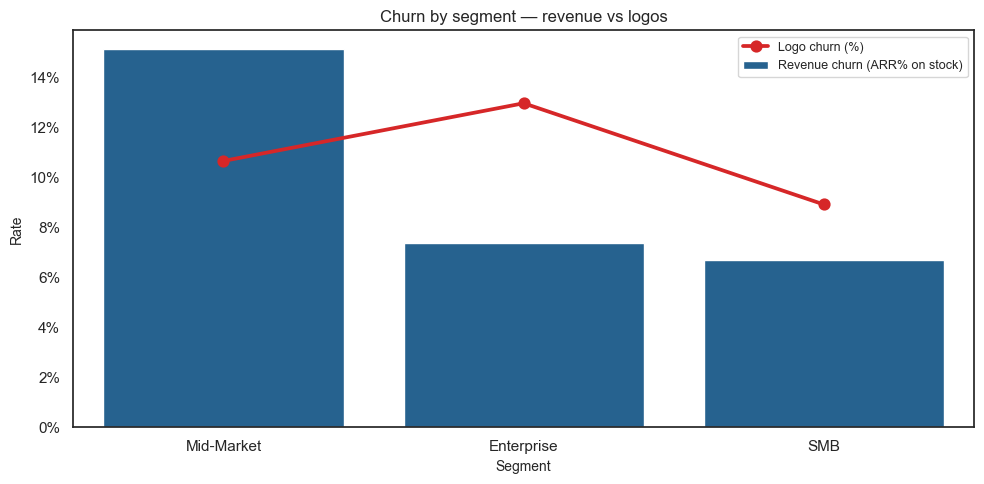

In [197]:

fig, ax = plt.subplots(figsize=(10,5))
order = seg.sort_values('rev_churn_ratio_on_stock', ascending=False)['segment']
sns.barplot(
    data=seg, x='segment', y='rev_churn_ratio_on_stock', order=order,
    color='#1565a0', label='Revenue churn (ARR% on stock)')
sns.pointplot(
    data=seg, x='segment', y='logos_churn', order=order, color='#d62728', label='Logo churn (%)')
ax.set_title('Churn by segment — revenue vs logos')
ax.set_xlabel('Segment')
ax.set_ylabel('Rate')
ax.yaxis.set_major_formatter(lambda x,pos: f"{x*100:.0f}%")
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()



## Regions — GRR/NRR & churn


In [186]:

reg = df.groupby('region').agg(
    opening=('opening_arr','sum'),
    arr=('annual_contract_value','sum'),
    churn=('churned_arr','sum'),
    new=('new_arr','sum'),
    react=('reactivated_arr','sum'),
    exp=('expansion_arr','sum'),
    cont=('contraction_arr','sum'),
    accounts=('account_id','nunique'),
    logos_churn=('churned_arr', lambda s: (s>0).mean())
).reset_index()
reg['rev_churn_ratio_on_stock'] = reg['churn'] / reg['arr']
reg['gross_churn_on_opening'] = reg['churn'] / reg['opening']
reg['GRR'] = 1 - reg['gross_churn_on_opening']
reg['NRR'] = (reg['opening'] - reg['churn'] + reg['exp'] - reg['cont']) / reg['opening']

reg_fmt = reg.copy()
for c in ['opening','arr','churn','new','react','exp','cont']:
    reg_fmt[c] = reg_fmt[c].apply(fmt_usd)
for c in ['rev_churn_ratio_on_stock','gross_churn_on_opening','GRR','NRR','logos_churn']:
    reg_fmt[c] = reg_fmt[c].apply(fmt_pct)
reg_fmt


,region,opening,arr,churn,new,react,exp,cont,accounts,logos_churn,rev_churn_ratio_on_stock,gross_churn_on_opening,GRR,NRR
0,APAC,906 228 $,2 810 220 $,159 456 $,1 578 324 $,506 484 $,0 $,0 $,81,8.6%,5.7%,17.6%,82.4%,82.4%
1,EMEA,819 900 $,3 905 028 $,310 800 $,1 862 616 $,904 308 $,0 $,0 $,105,13.3%,8.0%,37.9%,62.1%,62.1%
2,NAM,3 165 552 $,8 118 768 $,969 672 $,5 840 508 $,2 366 256 $,0 $,0 $,314,10.5%,11.9%,30.6%,69.4%,69.4%



## Prioritization matrix — Region × Segment net contribution (% of Region ARR)

This normalizes **Net ARR** by **Region ARR** to avoid size bias and quickly spot cells that deserve attention.


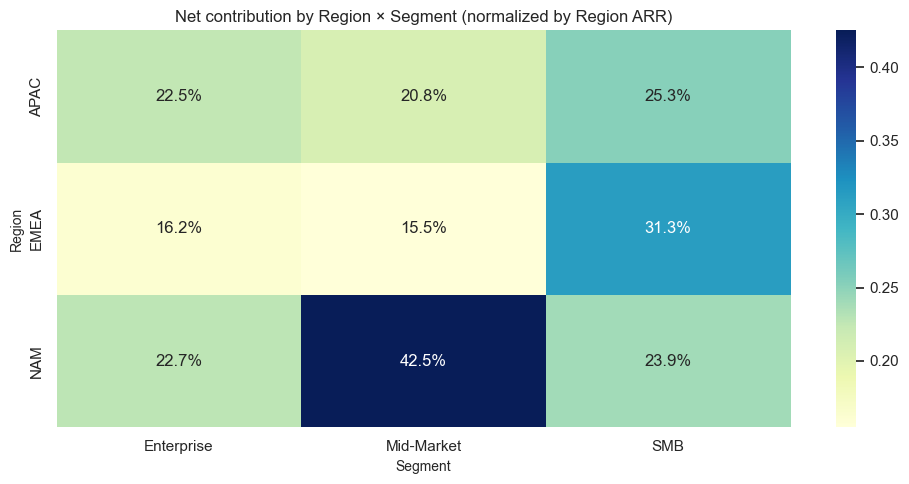

In [187]:

# Build Region x Segment matrix on normalized Net/ARR_region
agg = df.groupby(['region','segment']).agg(
    arr=('annual_contract_value','sum'),
    net=('net_arr_change','sum')
).reset_index()
reg_arr = agg.groupby('region')['arr'].sum().rename('arr_region')
agg = agg.merge(reg_arr, on='region', how='left')
agg['net_pct_region'] = np.where(agg['arr_region']>0, agg['net']/agg['arr_region'], 0.0)

pivot = agg.pivot(index='region', columns='segment', values='net_pct_region').fillna(0.0)

fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='YlGnBu', cbar=True, ax=ax)
ax.set_title('Net contribution by Region × Segment (normalized by Region ARR)')
ax.set_xlabel('Segment')
ax.set_ylabel('Region')
plt.tight_layout()
plt.show()



## Waterfalls — Global and by segment


In [188]:
# # 1) Global waterfall (M$)
# to_musd = lambda x: x / 1e6
# fmt_musd = lambda x: f"{x:,.1f} M$"
# steps = ['Opening','- Churn','+ Reactivation','+ New','Closing']
# amounts = [opening_total, -churned_total, reactivated_total, new_total, opening_total - churned_total + reactivated_total + new_total]
# colors_global = ['#1f77b4','#e15759','#2ca02c','#2ca02c','#1f77b4']  # opening/closing blue, churn red, react/new green

# # Compute start/end for each bar (waterfall logic)
# y_start = []
# y_end = []
# cum = 0
# for i, amt in enumerate(amounts):
#     if i == len(amounts)-1:  # final total from 0
#         start = 0
#         end = amounts[-1]
#     else:
#         start = cum
#         end = cum + amt
#         cum = end
#     y_start.append(start)
#     y_end.append(end)

# fig, ax = plt.subplots(figsize=(10,4))
# for i,(step,amt,color,start,end) in enumerate(zip(steps, amounts, colors_global, y_start, y_end)):
#     height = end - start
#     bottom = start
#     ax.bar(i, to_musd(height), bottom=to_musd(bottom), color=color, edgecolor='white', linewidth=0.6)
#     ax.text(i, to_musd(bottom) + to_musd(height)/2 if height!=0 else to_musd(bottom), fmt_musd(height), ha='center', va='center', color='white', fontsize=9)
# ax.set_xticks(range(len(steps)))
# ax.set_xticklabels(steps)
# ax.set_ylabel('ARR (M$)')
# ax.set_title('Global ARR Waterfall')
# ax.set_ylim(bottom=min(0, to_musd(min(y_start + y_end))))
# plt.tight_layout()
# plt.show()

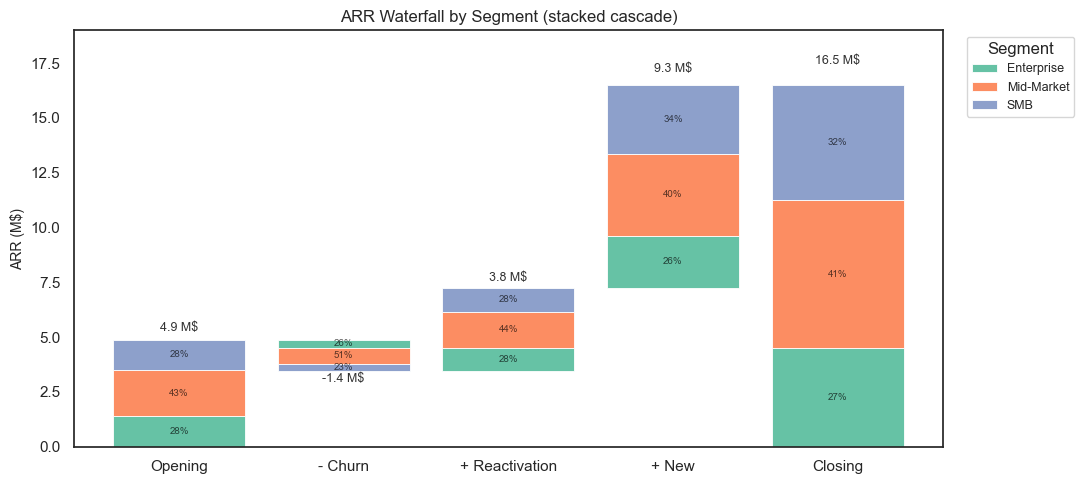

In [199]:

# 2) Stacked waterfall by segment (cascade, M$) with connectors and % overlays
fmt_pct1 = lambda x: f"{x*100:.0f}%"

seg_water = df.groupby('segment').agg(
    opening=('opening_arr','sum'),
    churn=('churned_arr','sum'),
    react=('reactivated_arr','sum'),
    new=('new_arr','sum')
).reset_index()
seg_water['churn'] = -seg_water['churn']  # ensure churn is negative for waterfall
seg_water['closing'] = seg_water['opening'] + seg_water['churn'] + seg_water['react'] + seg_water['new']
steps_order = ['Opening','- Churn','+ Reactivation','+ New','Closing']
value_cols = ['opening','churn','react','new','closing']
step_map = dict(zip(value_cols, steps_order))

long = seg_water.melt(id_vars='segment', value_vars=value_cols, var_name='step_key', value_name='value')
long['Step'] = long['step_key'].map(step_map)
long['value_m'] = long['value'].apply(to_musd)
segments = long['segment'].unique().tolist()
colors = sns.color_palette('Set2', n_colors=len(segments))
color_map = dict(zip(segments, colors))

# total per step to drive cumulative path
step_totals = long.groupby('Step')['value_m'].sum().reindex(steps_order)
y_start_tot = []
y_end_tot = []
cum = 0
for i, step in enumerate(steps_order):
    if step == 'Opening':
        start = 0; end = step_totals.loc[step]; cum = end
    elif step == 'Closing':
        start = 0; end = step_totals.loc[step]
    else:
        start = cum; end = cum + step_totals.loc[step]; cum = end
    y_start_tot.append(start)
    y_end_tot.append(end)

fig, ax = plt.subplots(figsize=(11,5))
min_y = 0
for x, step in enumerate(steps_order):
    step_df = long[long['Step']==step]
    step_total = step_totals.loc[step]
    base = 0 if step in ['Opening','Closing'] else y_start_tot[x]
    pos_bottom = base
    neg_bottom = base
    for seg_name in segments:
        v_series = step_df.loc[step_df['segment']==seg_name, 'value_m']
        if v_series.empty:
            continue
        v = v_series.iloc[0]
        if v >= 0:
            ax.bar(x, v, bottom=pos_bottom, color=color_map[seg_name], edgecolor='white', linewidth=0.6, label=seg_name if x==0 else "")
            if step not in ['Closing'] and step_total != 0:
                ax.text(x, pos_bottom + v/2, fmt_pct1(v/step_total), ha='center', va='center', fontsize=7, color='black', alpha=0.65)
            pos_bottom += v
        else:
            ax.bar(x, v, bottom=neg_bottom, color=color_map[seg_name], edgecolor='white', linewidth=0.6, label=seg_name if x==0 else "")
            if step not in ['Closing'] and step_total != 0:
                ax.text(x, neg_bottom + v/2, fmt_pct1(v/step_total), ha='center', va='center', fontsize=7, color='black', alpha=0.65)
            neg_bottom += v
        min_y = min(min_y, neg_bottom)
  
    # total label with offset to avoid overlapping bars (especially churn)
    label_offset = max(0.05 * abs(step_total), 0.05)
    label_y = (pos_bottom + label_offset) if step_total >= 0 else (neg_bottom - label_offset)
    ax.text(x, label_y, fmt_musd(step_total), ha='center', va='bottom' if step_total>=0 else 'top', fontsize=9, color='#333')
  
    # add per-segment labels on closing too
    if step == 'Closing' and step_total != 0:
        step_df = step_df.sort_values('value_m', ascending=False)
        running = 0
        for seg_name in segments:
            v_series = step_df.loc[step_df['segment']==seg_name, 'value_m']
            if v_series.empty:
                continue
            v = v_series.iloc[0]
            center = running + v/2
            ax.text(x, center, fmt_pct1(v/step_total), ha='center', va='center', fontsize=7, color='black', alpha=0.65)
            running += v

ax.set_xticks(range(len(steps_order)))
ax.set_xticklabels(steps_order)
ax.set_title('ARR Waterfall by Segment (stacked cascade)')
ax.set_ylabel('ARR (M$)')

# Adjust ylim to keep total labels inside frame
y_all = y_end_tot + y_start_tot + [0, min(0, min_y)]
y_max_axis = max(y_all)
y_range = y_max_axis if y_max_axis > 0 else 1
ax.set_ylim(bottom=0, top=y_max_axis + 0.15*y_range)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(False)
plt.tight_layout()
plt.show()



## Benchmarks & definitions 

**Typical ranges (order of magnitude, vary by product & motion):**
- **SMB** gross churn: ~20–35% annual; **Mid‑Market**: ~8–15%; **Enterprise**: ~2–8%
- **Healthy GRR** often **> 90%** (MM/ENT), **NRR** 
  - SMB motion: 100–110% common (if expansion is modest)
  - Enterprise motion: 110–130%+ when expansion is strong

> Notes: This dataset intentionally simulates **acquisition‑led growth** with **fragile retention** and **reactivations**, so absolute levels may be worse than best‑in‑class benchmarks — that is by design.
